# 06 · Anomaly Detection — Multivariate SPC without labels

Step 5 showed that October's failures follow a *new* pattern that no model trained on earlier failures could learn.
Can an **unsupervised** detector, which only learns what *normal* production looks like, do better?

Code: [`src/anomaly.py`](../src/anomaly.py), tests: [`tests/test_anomaly.py`](../tests/test_anomaly.py).

| Statistic | Question it answers |
|---|---|
| **Hotelling T²** (PCA scores) | Is the unit extreme *within* the normal pattern of sensor co-variation? |
| **SPE / Q** (PCA residual) | Does the unit *break* the normal relationships between sensors? |
| **Isolation Forest** | Non-linear second opinion: is the unit easy to isolate? |

- Baseline = **Pass units of the train period** (all 272 cleaned sensors, no label-based selection).
- Control limits = 99th percentile of **out-of-fold** baseline scores (target: ~1% false alarms). Empirical
  percentiles because the sensors are far from normal (Step 3).
- **Contribution analysis** names the sensors behind every alarm.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.anomaly import AnomalyDetector

FIG_DIR = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
PASS_C, FAIL_C, INK, ALARM_C = "#2a9d8f", "#e76f51", "#264653", "#d62828"

train = pd.read_csv(ROOT / "data/processed/train_clean.csv", parse_dates=["timestamp"])
test = pd.read_csv(ROOT / "data/processed/test_clean.csv", parse_dates=["timestamp"])
scores = pd.read_csv(ROOT / "data/processed/anomaly_scores.csv", parse_dates=["timestamp"])
det = joblib.load(ROOT / "models/anomaly_detector.joblib")
sensors = [c for c in train.columns if c.startswith("sensor_")]
baseline = train[train.fail == 0]
print(f"Baseline: {len(baseline)} Pass units x {len(sensors)} sensors | PCA components kept: {det.n_components_}")

Baseline: 1095 Pass units x 272 sensors | PCA components kept: 36


## 1. How much shared structure do the sensors have?

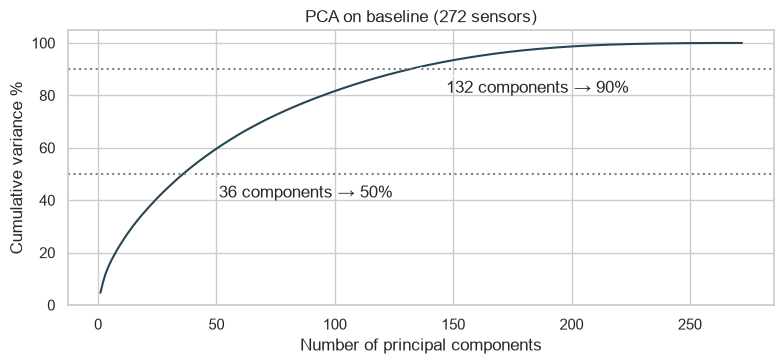

In [2]:
pca_full = PCA().fit(StandardScaler().fit_transform(baseline[sensors]))
cum = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(np.arange(1, len(cum) + 1), cum * 100, color=INK)
for v in [0.5, 0.9]:
    k = int(np.searchsorted(cum, v) + 1)
    ax.axhline(v * 100, ls=":", color="grey")
    ax.annotate(f"{k} components → {v:.0%}", (k, v * 100), xytext=(k + 15, v * 100 - 9), arrowprops=dict(arrowstyle="->"))
ax.set(xlabel="Number of principal components", ylabel="Cumulative variance %", title="PCA on baseline (272 sensors)")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_pca_variance.png", dpi=150)
plt.show()

After removing near-duplicate sensors in Step 2, the remaining sensors share little structure:
~130 components are needed for 90% of the variance. A compact "normal plane" does not exist, which already
limits what PCA-based monitoring can do.

## 2. Choosing the settings — using the train period only

Forward check inside the train period: fit the detector on Pass units of **Jul–Aug** and score **September**.
Two things are measured: the false-alarm rate on September's *Pass* units, and how well the scores rank September's failures (ROC-AUC).

In [3]:
early, late = train[train.timestamp < "2008-09-01"], train[train.timestamp >= "2008-09-01"]
b0 = early[early.fail == 0]
rows = []
for transform in ["none", "clip ±5σ"]:
    prep = (lambda d: d[sensors]) if transform == "none" else (lambda d: d[sensors].clip(-5, 5))
    for v in [0.5, 0.9]:
        d = AnomalyDetector(variance=v).fit(prep(b0))
        s = d.score(prep(late))
        rows.append({"transform": transform, "variance": v, "components": d.n_components_,
                     "false alarms (Sep Pass)": s.loc[late.fail.values == 0, "mspc_alarm"].mean(),
                     "AUC T²": roc_auc_score(late.fail, s.t2), "AUC SPE": roc_auc_score(late.fail, s.spe),
                     "AUC IsoForest": roc_auc_score(late.fail, s.iso_score)})
setting = pd.DataFrame(rows)
setting.style.format({"false alarms (Sep Pass)": "{:.1%}", "AUC T²": "{:.2f}", "AUC SPE": "{:.2f}", "AUC IsoForest": "{:.2f}"})

,transform,variance,components,false alarms (Sep Pass),AUC T²,AUC SPE,AUC IsoForest
0,none,0.500000,31,2.0%,0.66,0.59,0.68
1,none,0.900000,116,1.7%,0.60,0.51,0.68
2,clip ±5σ,0.500000,31,58.5%,0.71,0.57,0.70
3,clip ±5σ,0.900000,119,60.3%,0.59,0.51,0.70


- **Clipping** the heavy tails makes the limits tight, and then **~60% of good September units raise an alarm**.
  The detector is picking up the process *shift* between August and September, not individual bad units.
  That is a drift signal, but useless as a per-unit alarm.
- **No transform, 50% variance** keeps false alarms at ~2% and ranks September failures modestly (AUC ≈ 0.66–0.68).

➡️ Chosen: raw scaled sensors, PCA with 50% variance (36 components on the full baseline).

*Transparency note:* before this train-period check, a first configuration (90% variance, 132 components) was
scored once on the test period. It also caught 0 of 24 failures, so the revision did not flatter the test result.

## 3. Test period — do anomalies predict failure?

In [4]:
t = scores[scores.period == "test"]
rows = []
for name, flag, score in [("Hotelling T²", "t2_alarm", "t2"), ("SPE / Q", "spe_alarm", "spe"),
                          ("T² or SPE (MSPC)", "mspc_alarm", "t2"), ("Isolation Forest", "iso_alarm", "iso_score")]:
    rows.append({"method": name, "units flagged": t[flag].mean(), "false alarms (Pass)": t.loc[t.fail == 0, flag].mean(),
                 "fails caught": f"{int(t.loc[t.fail == 1, flag].sum())}/{int(t.fail.sum())}",
                 "ROC-AUC of score": roc_auc_score(t.fail, t[score])})
pd.DataFrame(rows).style.format({"units flagged": "{:.1%}", "false alarms (Pass)": "{:.1%}", "ROC-AUC of score": "{:.2f}"})

,method,units flagged,false alarms (Pass),fails caught,ROC-AUC of score
0,Hotelling T²,2.6%,2.7%,0/24,0.50
1,SPE / Q,3.3%,3.5%,0/24,0.48
2,T² or SPE (MSPC),3.6%,3.8%,0/24,0.50
3,Isolation Forest,1.0%,1.1%,0/24,0.53


**No.** The detector flags ~4% of test units, catches **0 of 24 failures**, and its scores rank failures at
chance level (AUC ≈ 0.5). October's failed units look **completely normal** in sensor space.

Together with Step 5 this is a consistent pattern: **October's yield loss is not detectable in these 590 sensors
with the methods tried**, supervised or unsupervised. That suggests, but does not prove, that the driver lies in a
process step or measurement the dataset does not contain. The right next action is to widen data collection, not to tune models further.

## 4. What the detector *does* find: sensor and tool events

In [5]:
flagged = t[t.mspc_alarm].copy()
flagged["main_sensor"] = flagged.top_sensors.str.split(", ").str[0]
flagged["severity (×limit)"] = flagged[["t2_ratio", "spe_ratio"]].max(axis=1)
events = (flagged.groupby("main_sensor")
          .agg(units=("unit_id", "count"), first=("timestamp", "min"), last=("timestamp", "max"),
               fails=("fail", "sum"), max_severity=("severity (×limit)", "max"))
          .sort_values("units", ascending=False))
events.style.format({"max_severity": "{:,.1f}", "first": "{:%d %b %H:%M}", "last": "{:%d %b %H:%M}"})

,units,first,last,fails,max_severity
main_sensor,,,,,
sensor_007,6,10 Oct 12:30,12 Oct 03:21,0,3.2
sensor_140,4,05 Oct 00:33,11 Oct 06:56,0,"626,291.3"
sensor_248,2,29 Sep 14:03,08 Oct 09:01,0,1.4
sensor_202,1,11 Oct 07:39,11 Oct 07:39,0,5.3
sensor_252,1,30 Sep 19:17,30 Sep 19:17,0,"2,288.2"


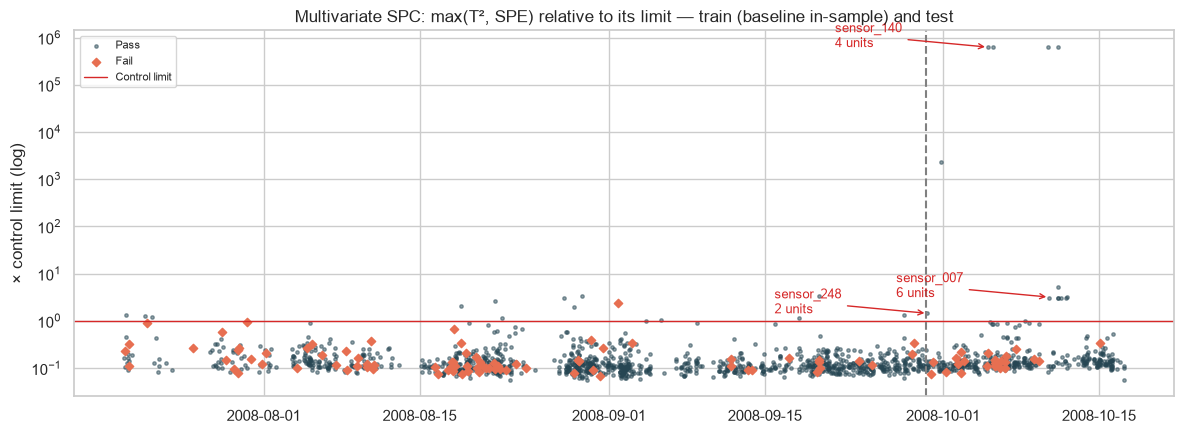

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))
sev = scores[["t2_ratio", "spe_ratio"]].max(axis=1)
ax.scatter(scores.timestamp[scores.fail == 0], sev[scores.fail == 0], s=6, color=INK, alpha=0.5, label="Pass")
ax.scatter(scores.timestamp[scores.fail == 1], sev[scores.fail == 1], s=18, color=FAIL_C, marker="D", label="Fail")
ax.axhline(1, color=ALARM_C, lw=1, label="Control limit")
ax.axvline(test.timestamp.min(), color="grey", ls="--")
ax.set_yscale("log")
for sensor, row in events.head(3).iterrows():
    y = flagged.loc[flagged.main_sensor == sensor, "severity (×limit)"].max()
    ax.annotate(f"{sensor}\n{row.units} units", (row["first"], y), xytext=(-110, 0), textcoords="offset points",
                fontsize=9, color=ALARM_C, arrowprops=dict(arrowstyle="->", color=ALARM_C))
ax.set(title="Multivariate SPC: max(T², SPE) relative to its limit — train (baseline in-sample) and test",
       ylabel="× control limit (log)")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_mspc_timeline.png", dpi=150)
plt.show()

Train-period Pass units are the baseline itself (in-sample), so few of them cross the limit. In the test period
all 14 alarms are on units that **passed** the final test. Two stand out: a massive `sensor_140` excursion and a
`sensor_007` burst.

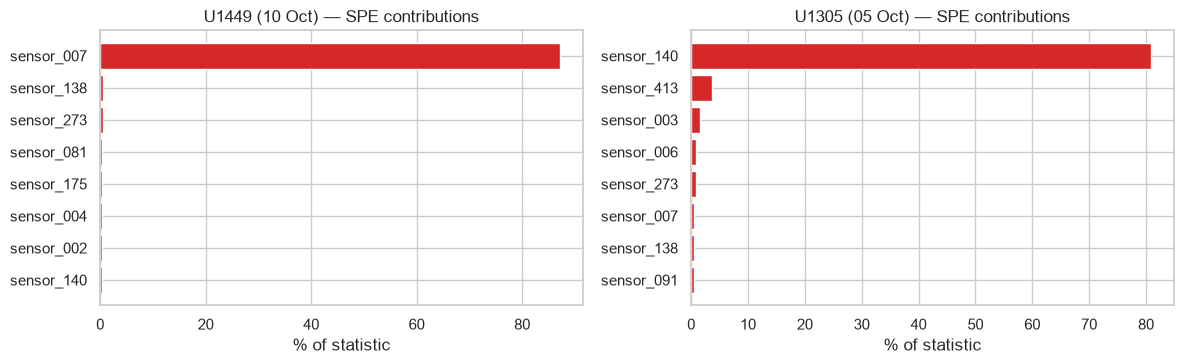

In [7]:
examples = [flagged.loc[flagged.main_sensor == s].iloc[0] for s in events.index[:2]]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
X_all = pd.concat([train, test], ignore_index=True)
for ax, ex in zip(axes, examples):
    x = X_all.loc[X_all.unit_id == ex.unit_id, sensors]
    contrib = (det.spe_contributions(x) if ex.driver == "SPE" else det.t2_contributions(x)).iloc[0]
    share = (contrib / contrib.sum()).sort_values(ascending=False).head(8)
    ax.barh(share.index[::-1], share.values[::-1] * 100, color=ALARM_C)
    ax.set(title=f"{ex.unit_id} ({ex.timestamp:%d %b}) — {ex.driver} contributions", xlabel="% of statistic")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_contributions.png", dpi=150)
plt.show()

**Contribution analysis turns an alarm into an action.**
- **`sensor_140` (4 units, 5–11 Oct):** readings of ≈ 9999 put these units hundreds of thousands of times over the
  limit. The detector finds the sensor behind it automatically, among 272 candidates. In Step 3 it was found by
  manual inspection. **Action:** metrology / data-acquisition check.
- **`sensor_007` (6 units in ~2 days, 10–12 Oct):** a short burst that breaks the normal sensor relationships
  (SPE) without affecting yield. **Action:** inspect the tool behind `sensor_007` for that shift.
- **`sensor_252` (30 Sep):** a single unit at ~2 300× the limit; `sensor_252` was also among the most-shifted sensors in the Step 2 drift check.
- `sensor_248` (2 units, 9 days apart, only 1.0–1.4× the limit) and `sensor_202` (1 unit, 5×) are marginal and
  most likely ordinary noise at a 1% false-alarm rate.

## 5. Takeaways

| # | Finding | Meaning |
|---|---|---|
| 1 | After de-duplication, sensors share little structure (~130 PCs for 90% variance) | Compact PCA monitoring is hard on this data |
| 2 | Clipped/rank-transformed limits alarm on ~60% of good units in the next month | Month-to-month process shift: a drift signal, not a unit-level alarm |
| 3 | On the test period the detector catches 0/24 failures (AUC ≈ 0.5) | Together with Step 5: October's yield loss is **not visible** in these sensors |
| 4 | It automatically finds sensor/tool events (`sensor_140` ≈ 9999 readings, a `sensor_007` burst, a `sensor_252` spike), all on passing units | Its real value is **equipment and sensor health monitoring**, with root cause attached |

**Platform view:** Steps 3–6 now give four complementary signals: SPC per sensor (stability), the fail model
(risk ranking), MSPC/Isolation Forest (sensor/tool health) and the drift checks. Step 7 puts them in one dashboard.

**Outputs:** `models/anomaly_detector.joblib`, `data/processed/anomaly_scores.csv` (T², SPE, Isolation Forest score, flags and
top contributing sensors per unit).